In [1]:
import pandas as pd
import re
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Descriptors

# ---------- Paths ----------
BASE = Path(r"G:\내 드라이브\★Works\NP and ML\Huangqi")
XLSX = BASE / "Huangqi_QED_Filtered_With_CID.xlsx"
SHEET = "Curated"

STITCH = BASE / "9606.protein_chemical.links.v5.0.tsv"
PINFO = BASE / "9606.protein.info.v12.0.txt"

OUT = BASE / "out_stage2_v2"
OUT.mkdir(exist_ok=True)

SCORE_CUTOFF = 700

# ---------- Stage 1: compound druggable phytochemical ----------
cmpd = pd.read_excel(XLSX, sheet_name=SHEET).copy()
cmpd["PubChem_CID"] = pd.to_numeric(cmpd["PubChem_CID"], errors="coerce")
cmpd = cmpd.dropna(subset=["PubChem_CID"]).copy()
cmpd["PubChem_CID"] = cmpd["PubChem_CID"].astype(int)

def props(smiles):
    m = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) else None
    if m is None:
        return None, None
    return Descriptors.MolWt(m), m.GetNumHeavyAtoms()

cmpd[["MolWt","HeavyAtoms"]] = cmpd["Canonical_SMILES"].apply(lambda s: pd.Series(props(s)))

# noise 제거 룰 (조정 가능)
cmpd_f = cmpd[(cmpd["MolWt"] >= 200) & (cmpd["HeavyAtoms"] >= 14)].copy()
cid_set = set(cmpd_f["PubChem_CID"].unique())

cmpd_f[["label","Extracted_ID","PubChem_CID","Canonical_SMILES","QED","MolWt","HeavyAtoms"]]\
    .drop_duplicates("PubChem_CID")\
    .to_csv(OUT / "compound_curated_druggable.tsv", sep="\t", index=False)

print("[INFO] compounds kept:", len(cid_set))

# ---------- Stage 2: STITCH candidate generation ----------
CIDM_RE = re.compile(r"^CIDm0*([0-9]+)$")
def cid_from_stitch(x):
    if not isinstance(x, str): return None
    m = CIDM_RE.match(x.strip())
    return int(m.group(1)) if m else None

links = pd.read_csv(STITCH, sep="\t", dtype=str)
links["combined_score"] = pd.to_numeric(links["combined_score"], errors="coerce")
links = links.dropna(subset=["combined_score"]).copy()

links["PubChem_CID"] = links["chemical"].map(cid_from_stitch)
links = links.dropna(subset=["PubChem_CID"]).copy()
links["PubChem_CID"] = links["PubChem_CID"].astype(int)

ct = links[(links["PubChem_CID"].isin(cid_set)) & (links["combined_score"] >= SCORE_CUTOFF)].copy()
ct = ct[["PubChem_CID","protein","combined_score"]].rename(columns={"protein":"protein_id"})
ct.to_csv(OUT / f"ct_stitch_score{SCORE_CUTOFF}.tsv", sep="\t", index=False)
print("[INFO] edges:", len(ct))

# ---------- protein_id -> gene_symbol mapping ----------
prot = pd.read_csv(PINFO, sep="\t", dtype=str)
prot = prot[["#string_protein_id","preferred_name"]].drop_duplicates()\
           .rename(columns={"#string_protein_id":"protein_id","preferred_name":"gene_symbol"})

ctg = ct.merge(prot, on="protein_id", how="left")
ctg["gene_symbol"] = ctg["gene_symbol"].replace({"": None, "nan": None, "None": None})
ctg = ctg.dropna(subset=["gene_symbol"]).copy()

# compound meta merge
meta = cmpd_f[["PubChem_CID","label","Extracted_ID","Canonical_SMILES","QED"]].drop_duplicates("PubChem_CID")
ctg = ctg.merge(meta, on="PubChem_CID", how="left")

ctg.to_csv(OUT / f"ct_stitch_score{SCORE_CUTOFF}_gene.tsv", sep="\t", index=False)
print("[INFO] mapped edges:", len(ctg), "unique genes:", ctg["gene_symbol"].nunique())

# ---------- Stage 4: axis tagging (NO filtering) ----------
axis = {
    # HIF/EPO core
    "EPO_axis": {"EPOR","JAK2","STAT5A","STAT5B","PIK3CA","AKT1","MAPK1","MAPK3"},
    "HIF_axis": {"HIF1A","EPAS1","ARNT","VHL","EGLN1","EGLN2","EGLN3","HIF1AN"},
    "EPO_regulation": {"HNF4A","GATA2","GATA3"},
    "Iron_axis": {"HAMP","SLC40A1","TFRC","SLC11A2","HMOX1","GDF15"},
    "Microenvironment": {"ITGA4","VCAM1"},
}

def tag_gene(g):
    tags = [k for k,v in axis.items() if g in v]
    return "|".join(tags) if tags else ""

ctg["axis_tag"] = ctg["gene_symbol"].apply(tag_gene)

# axis priority score: tag 있을수록 + 가중치(원하면 수정)
ctg["axis_priority"] = ctg["axis_tag"].apply(lambda x: 0 if x=="" else len(x.split("|")))

ctg.to_csv(OUT / f"ct_tagged_score{SCORE_CUTOFF}.tsv", sep="\t", index=False)
print("[DONE] Saved:", OUT / f"ct_tagged_score{SCORE_CUTOFF}.tsv")

[INFO] compounds kept: 149
[INFO] edges: 222
[INFO] mapped edges: 168 unique genes: 161
[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\ct_tagged_score700.tsv


In [2]:
print(ctg["gene_symbol"].nunique())
print(ctg["label"].nunique())
print(len(ctg))

161
14
168


In [3]:
import pandas as pd

f = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\ct_tagged_score700.tsv"
ctg = pd.read_csv(f, sep="\t")

print("[INFO] edges:", len(ctg))
print("[INFO] compounds:", ctg["PubChem_CID"].nunique(), "labels:", ctg["label"].nunique())
print("[INFO] genes:", ctg["gene_symbol"].nunique())

# 1) axis tag 분포
print("\n[INFO] axis_tag counts:")
print(ctg["axis_tag"].fillna("").replace({"": "UNLABELED"}).value_counts())

# 2) axis에 해당하는 edge만
axis_edges = ctg[ctg["axis_tag"].fillna("") != ""].copy()
print("\n[INFO] axis_edges:", len(axis_edges))
if len(axis_edges) > 0:
    print(axis_edges["axis_tag"].value_counts())
    print("\n[INFO] axis targets found:", sorted(axis_edges["gene_symbol"].unique()))

# 3) top compounds / top targets
print("\n[INFO] Top compounds by degree:")
print(ctg["label"].value_counts().head(20))

print("\n[INFO] Top targets by degree:")
print(ctg["gene_symbol"].value_counts().head(30))

# 4) top edges by score
print("\n[INFO] Top edges by combined_score:")
print(ctg.sort_values("combined_score", ascending=False).head(20)[
    ["label","PubChem_CID","gene_symbol","combined_score","axis_tag"]
])

[INFO] edges: 168
[INFO] compounds: 14 labels: 14
[INFO] genes: 161

[INFO] axis_tag counts:
axis_tag
UNLABELED           162
Iron_axis             3
EPO_axis              2
Microenvironment      1
Name: count, dtype: int64

[INFO] axis_edges: 6
axis_tag
Iron_axis           3
EPO_axis            2
Microenvironment    1
Name: count, dtype: int64

[INFO] axis targets found: ['GDF15', 'HMOX1', 'MAPK1', 'MAPK3', 'VCAM1']

[INFO] Top compounds by degree:
label
5,7,4'-trihydroxyisoflavone                                                          122
6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimethoxyisoflavan-7-O-β-D-glucopyranoside      8
patchouli alcohol                                                                      6
quercetin                                                                              6
3-hydroxyflavanone                                                                     5
kaempferol                                                                             5
8,3'-d

In [4]:
import pandas as pd

in_file = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\ct_tagged_score700.tsv"
out_pairs = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\graphdta_candidates_score700.tsv"

TOP_N_TARGETS = 30     # unlabeled target 상위 N개
TOP_K_PER_TARGET = 8   # target당 상위 compound 수
TOP_K_PER_COMPOUND = 15  # compound별 최대 edge 수(허브 방지)

df = pd.read_csv(in_file, sep="\t")

# axis targets (seed)
axis_targets = set(df.loc[df["axis_tag"].fillna("") != "", "gene_symbol"].unique())

# unlabeled targets: target별 최고 score로 랭크
unlabeled = df[df["axis_tag"].isna() | (df["axis_tag"].fillna("") == "")].copy()
top_targets = (
    unlabeled.sort_values("combined_score", ascending=False)
             .groupby("gene_symbol", as_index=False)
             .first()
             .sort_values("combined_score", ascending=False)
             .head(TOP_N_TARGETS)["gene_symbol"]
)
top_targets = set(top_targets)

selected_targets = axis_targets.union(top_targets)
print("[INFO] axis targets:", len(axis_targets), sorted(axis_targets))
print("[INFO] top unlabeled targets:", len(top_targets))
print("[INFO] selected targets total:", len(selected_targets))

# 타겟 필터 적용
df_sel = df[df["gene_symbol"].isin(selected_targets)].copy()

# (옵션) compound 허브 방지: compound별 상위 K개 edge만 유지
df_sel = (df_sel.sort_values("combined_score", ascending=False)
               .groupby("PubChem_CID", as_index=False)
               .head(TOP_K_PER_COMPOUND))

# target별 상위 K개 compound만 유지
pairs = (df_sel.sort_values("combined_score", ascending=False)
              .groupby("gene_symbol", as_index=False)
              .head(TOP_K_PER_TARGET))

# 최종 컬럼 (GraphDTA 입력용)
pairs = pairs[[
    "PubChem_CID","label","Canonical_SMILES","QED",
    "protein_id","gene_symbol","combined_score","axis_tag","axis_priority"
]].drop_duplicates()

pairs.to_csv(out_pairs, sep="\t", index=False)

print("[DONE] Saved:", out_pairs)
print("[INFO] pairs:", len(pairs))
print("[INFO] unique targets:", pairs["gene_symbol"].nunique())
print("[INFO] unique compounds:", pairs["PubChem_CID"].nunique())

[INFO] axis targets: 5 ['GDF15', 'HMOX1', 'MAPK1', 'MAPK3', 'VCAM1']
[INFO] top unlabeled targets: 30
[INFO] selected targets total: 35
[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\graphdta_candidates_score700.tsv
[INFO] pairs: 36
[INFO] unique targets: 32
[INFO] unique compounds: 11


In [5]:
import sys
sys.path.append(r"G:\내 드라이브\★Works\NP and ML\Huangqi\GraphDTA")
import pandas as pd
import gzip
from pathlib import Path

graphdta_repo = Path(r"G:\내 드라이브\★Works\NP and ML\Huangqi\GraphDTA")
pairs_tsv = Path(r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\graphdta_candidates_score700.tsv")
fasta_gz = Path(r"G:\내 드라이브\★Works\NP and ML\Huangqi\9606.protein.sequences.v12.0.fa.gz")

out_dir = graphdta_repo / "data" / "custom_pred" / "raw"
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / "custom_pred.csv"

pairs = pd.read_csv(pairs_tsv, sep="\t")
needed = set(pairs["protein_id"].unique())

# FASTA.gz에서 필요한 protein_id만 추출
seq_map = {}
cur_id = None
buf = []

with gzip.open(fasta_gz, "rt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if cur_id and cur_id in needed:
                seq_map[cur_id] = "".join(buf)
            cur_id = line[1:].split()[0]
            buf = []
        else:
            if cur_id in needed:
                buf.append(line)

if cur_id and cur_id in needed:
    seq_map[cur_id] = "".join(buf)

pairs["target_sequence"] = pairs["protein_id"].map(seq_map)
pairs = pairs.dropna(subset=["target_sequence"]).copy()

# GraphDTA가 읽을 컬럼명으로 저장 (라벨/affinity 없음)
pred_in = pairs.rename(columns={"Canonical_SMILES": "compound_smiles"})[
    ["compound_smiles", "target_sequence", "PubChem_CID", "label", "protein_id", "gene_symbol", "combined_score", "axis_tag"]
]

pred_in.to_csv(out_csv, index=False)
print("[DONE] Saved:", out_csv, "n_pairs=", len(pred_in), "n_proteins=", pred_in["protein_id"].nunique())

[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\GraphDTA\data\custom_pred\raw\custom_pred.csv n_pairs= 36 n_proteins= 32


In [6]:
import os, sys

GRAPH_DTA_DIR = r"G:\내 드라이브\★Works\NP and ML\Huangqi\GraphDTA"

print("BEFORE cwd:", os.getcwd())
print("BEFORE sys.path[0:3]:", sys.path[0:3])

# 1) 작업 디렉토리 이동
os.chdir(GRAPH_DTA_DIR)

# 2) sys.path 맨 앞에 삽입 (append 말고 insert!)
if GRAPH_DTA_DIR not in sys.path:
    sys.path.insert(0, GRAPH_DTA_DIR)

print("AFTER cwd:", os.getcwd())
print("AFTER sys.path[0:3]:", sys.path[0:3])

# 3) utils.py 존재 확인
print("utils exists?:", os.path.exists(os.path.join(GRAPH_DTA_DIR, "utils.py")))
print("models exists?:", os.path.exists(os.path.join(GRAPH_DTA_DIR, "models")))

BEFORE cwd: G:\내 드라이브\★Works\NP and ML\Huangqi
BEFORE sys.path[0:3]: ['C:\\Users\\GM\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\GM\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\GM\\AppData\\Local\\Programs\\Python\\Python312\\Lib']
AFTER cwd: G:\내 드라이브\★Works\NP and ML\Huangqi\GraphDTA
AFTER sys.path[0:3]: ['C:\\Users\\GM\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\GM\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\GM\\AppData\\Local\\Programs\\Python\\Python312\\Lib']
utils exists?: True
models exists?: True


In [7]:
from utils import TestbedDataset
from models.ginconv import GINConvNet
print("IMPORT OK")

C:\Users\GM\gnn_env_final\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


IMPORT OK


In [8]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [9]:
import gzip
import pandas as pd
import torch
from torch_geometric.loader import DataLoader

from utils import TestbedDataset
from models.ginconv import GINConvNet

# ★중요: create_data.py에 있는 동일 전처리 함수를 반드시 사용해야 입력 차원이 맞습니다.
# GraphDTA repo의 create_data.py에 아래 함수명이 보통 존재합니다.
# - smile_to_graph(smiles) 또는 smiles_to_graph(smiles)
# - seq_cat(protein_sequence)
#
# 만약 이름이 다르면 create_data.py에서 함수명만 확인해서 아래 import를 바꿔주세요.
from create_data import smile_to_graph, seq_cat  # <- 함수명이 다르면 여기 수정

CANDIDATES_TSV = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\graphdta_candidates_score700.tsv"
FASTA_GZ = r"G:\내 드라이브\★Works\NP and ML\Huangqi\9606.protein.sequences.v12.0.fa.gz"
MODEL_PATH = r"G:\내 드라이브\★Works\NP and ML\Huangqi\GraphDTA\model_GINConvNet_davis_with_val.model"
OUT_CSV = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\graphdta_predictions_davis_val.csv"

CUDA_INDEX = 0
device = torch.device(f"cuda:{CUDA_INDEX}" if torch.cuda.is_available() else "cpu")

def load_fasta_map(fasta_gz_path, needed_ids:set):
    seq_map = {}
    cur_id = None
    buf = []
    with gzip.open(fasta_gz_path, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if cur_id and cur_id in needed_ids:
                    seq_map[cur_id] = "".join(buf)
                cur_id = line[1:].split()[0]
                buf = []
            else:
                if cur_id in needed_ids:
                    buf.append(line)
    if cur_id and cur_id in needed_ids:
        seq_map[cur_id] = "".join(buf)
    return seq_map

def main():
    df = pd.read_csv(CANDIDATES_TSV, sep="\t")
    needed = set(df["protein_id"].unique())

    seq_map = load_fasta_map(FASTA_GZ, needed)
    df["protein_sequence"] = df["protein_id"].map(seq_map)
    df = df.dropna(subset=["protein_sequence"]).copy()
    df = df.reset_index(drop=True)

    # 1) ligand graphs (unique SMILES)
    unique_smiles = df["Canonical_SMILES"].unique().tolist()
    smile_graph = {}
    for s in unique_smiles:
        c_size, features, edge_index = smile_to_graph(s)
        smile_graph[s] = (c_size, features, edge_index)

    # 2) encode protein sequences -> xt list
    xd = df["Canonical_SMILES"].tolist()
    xt = [seq_cat(seq) for seq in df["protein_sequence"].tolist()]

    # 3) y=None (라벨 없이)
    dataset_name = "huangqi_pred_davis"
    test_data = TestbedDataset(
        root="data",
        dataset=dataset_name,
        xd=xd,
        xt=xt,
        y=None,
        smile_graph=smile_graph
    )
    loader = DataLoader(test_data, batch_size=256, shuffle=False)

    # 4) load model
    model = GINConvNet().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    preds = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            preds.append(out.view(-1).detach().cpu())
    preds = torch.cat(preds).numpy()

    # 5) save
    out_df = df[["PubChem_CID","label","gene_symbol","protein_id","Canonical_SMILES","combined_score","axis_tag"]].copy()
    out_df["pred_davis"] = preds
    out_df.to_csv(OUT_CSV, index=False)
    print("[DONE] Saved:", OUT_CSV, "n=", len(out_df))

if __name__ == "__main__":
    main()

convert data from DeepDTA for  kiba

dataset: kiba
train_fold: 98545
test_fold: 19709
len(set(drugs)),len(set(prots)): 2068 229
convert data from DeepDTA for  davis

dataset: davis
train_fold: 25046
test_fold: 5010
len(set(drugs)),len(set(prots)): 68 379
data/processed/davis_train.pt  and  data/processed/davis_test.pt  are already created
data/processed/kiba_train.pt  and  data/processed/kiba_test.pt  are already created
Pre-processed data found: data\processed\huangqi_pred_davis.pt, loading ...
[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\graphdta_predictions_davis_val.csv n= 36


In [10]:
import pandas as pd

pred_file = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\graphdta_predictions_davis_val.csv"
df = pd.read_csv(pred_file)

# 0) 확인
print(df.columns.tolist())
print(df.head())

# 1) target별 Top 5 ligand
top5_by_target = (df.sort_values("pred_davis", ascending=False)
                    .groupby("gene_symbol", as_index=False)
                    .head(5))

out1 = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\top5_ligands_per_target_davis_val.csv"
top5_by_target.to_csv(out1, index=False)
print("[DONE] Saved:", out1)

# 2) compound별 multi-target profile (각 compound가 몇 타겟에서 상위권인지)
# 여기선 target별 top3에 몇 번 등장하는지 카운트
top3 = (df.sort_values("pred_davis", ascending=False)
          .groupby("gene_symbol", as_index=False)
          .head(3))

multi = (top3.groupby(["PubChem_CID","label"], as_index=False)
              .size()
              .sort_values("size", ascending=False))

out2 = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\compound_multitarget_top3count_davis_val.csv"
multi.to_csv(out2, index=False)
print("[DONE] Saved:", out2)

# 3) axis-tagged targets만 따로 (seed 축 결과만 보고 싶을 때)
axis_only = df[df["axis_tag"].notna() & (df["axis_tag"].astype(str) != "")].copy()
out3 = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\axis_only_predictions_davis_val.csv"
axis_only.to_csv(out3, index=False)
print("[DONE] Saved:", out3, "n=", len(axis_only))

['PubChem_CID', 'label', 'gene_symbol', 'protein_id', 'Canonical_SMILES', 'combined_score', 'axis_tag', 'pred_davis']
   PubChem_CID                                              label gene_symbol  \
0        60146  6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...      ADRA1A   
1        60146  6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...      ADRA1D   
2         4528                                  patchouli alcohol      SLC6A3   
3      5280961                        5,7,4'-trihydroxyisoflavone        ESR2   
4        60146  6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...      ADRA1B   

             protein_id                                   Canonical_SMILES  \
0  9606.ENSP00000369960  COc1ccc(C2COc3cc(OC4OC(COC(C)=O)C(O)C(O)C4O)cc...   
1  9606.ENSP00000368766  COc1ccc(C2COc3cc(OC4OC(COC(C)=O)C(O)C(O)C4O)cc...   
2  9606.ENSP00000270349                     CC1CCC2(O)C(C)(C)C3CCC2(C)C1C3   
3  9606.ENSP00000343925               O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12   
4  96

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2"
PRED = os.path.join(BASE, "graphdta_predictions_davis_val.csv")
OUTDIR = os.path.join(BASE, "figures")
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(PRED)
df["axis_tag"] = df["axis_tag"].fillna("")  # NaN -> ""
print(df.shape)
print(df.head(3))

(36, 8)
   PubChem_CID                                              label gene_symbol  \
0        60146  6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...      ADRA1A   
1        60146  6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...      ADRA1D   
2         4528                                  patchouli alcohol      SLC6A3   

             protein_id                                   Canonical_SMILES  \
0  9606.ENSP00000369960  COc1ccc(C2COc3cc(OC4OC(COC(C)=O)C(O)C(O)C4O)cc...   
1  9606.ENSP00000368766  COc1ccc(C2COc3cc(OC4OC(COC(C)=O)C(O)C(O)C4O)cc...   
2  9606.ENSP00000270349                     CC1CCC2(O)C(C)(C)C3CCC2(C)C1C3   

   combined_score axis_tag  pred_davis  
0             999             5.597164  
1             998             5.774562  
2             998             6.548963  


In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2"
PRED = os.path.join(BASE, "graphdta_predictions_davis_val.csv")
OUTDIR = os.path.join(BASE, "figures")
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(PRED)
df["axis_tag"] = df["axis_tag"].fillna("")  # NaN -> ""
print(df.shape)
print(df.head(3))

(36, 8)
   PubChem_CID                                              label gene_symbol  \
0        60146  6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...      ADRA1A   
1        60146  6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...      ADRA1D   
2         4528                                  patchouli alcohol      SLC6A3   

             protein_id                                   Canonical_SMILES  \
0  9606.ENSP00000369960  COc1ccc(C2COc3cc(OC4OC(COC(C)=O)C(O)C(O)C4O)cc...   
1  9606.ENSP00000368766  COc1ccc(C2COc3cc(OC4OC(COC(C)=O)C(O)C(O)C4O)cc...   
2  9606.ENSP00000270349                     CC1CCC2(O)C(C)(C)C3CCC2(C)C1C3   

   combined_score axis_tag  pred_davis  
0             999             5.597164  
1             998             5.774562  
2             998             6.548963  


In [13]:
# target별 top 3 ligand
topk = 3
tbl1 = (df.sort_values(["gene_symbol","pred_davis"], ascending=[True, False])
          .groupby("gene_symbol", as_index=False)
          .head(topk)
          .copy())

# 보기 좋게 정렬(축 타겟 먼저 보고 싶으면 아래 기준 추가)
tbl1 = tbl1.sort_values(["axis_tag","gene_symbol","pred_davis"], ascending=[False, True, False])

tbl1_out = os.path.join(BASE, f"Table1_top{topk}_ligands_per_target_davis_val.tsv")
tbl1.to_csv(tbl1_out, sep="\t", index=False)

print("[DONE] Saved:", tbl1_out)
tbl1.head(15)

[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\Table1_top3_ligands_per_target_davis_val.tsv


,PubChem_CID,label,gene_symbol,protein_id,Canonical_SMILES,combined_score,axis_tag,pred_davis
34,5280961,"5,7,4'-trihydroxyisoflavone",GDF15,9606.ENSP00000252809,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,837,Iron_axis,4.547130
32,137,isorhamnetin,HMOX1,9606.ENSP00000216117,COc1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O)ccc1O,861,Iron_axis,4.491257
33,5280961,"5,7,4'-trihydroxyisoflavone",HMOX1,9606.ENSP00000216117,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,839,Iron_axis,4.465668
0,60146,"6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...",ADRA1A,9606.ENSP00000369960,COc1ccc(C2COc3cc(OC4OC(COC(C)=O)C(O)C(O)C4O)cc...,999,,5.597164
4,60146,"6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...",ADRA1B,9606.ENSP00000306662,COc1ccc(C2COc3cc(OC4OC(COC(C)=O)C(O)C(O)C4O)cc...,994,,5.531087
1,60146,"6''-O-acetyl-(3R)-7,2'-dihydroxy-3',4'-dimetho...",ADRA1D,9606.ENSP00000368766,COc1ccc(C2COc3cc(OC4OC(COC(C)=O)C(O)C(O)C4O)cc...,998,,5.774562
17,1755,"(6aR,11aR)-10-hydroxy-3,9-dimethoxypterocarpan",ALAD,9606.ENSP00000386284,COc1ccc2c(c1)OCC1c3ccc(OC)c(O)c3OC21,959,,4.861537
6,137,isorhamnetin,ALAD,9606.ENSP00000386284,COc1cc(-c2oc3cc(O)cc(O)c3c(=O)c2O)ccc1O,987,,4.806120
16,5280961,"5,7,4'-trihydroxyisoflavone",AR,9606.ENSP00000363822,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,959,,4.812947
30,5280961,"5,7,4'-trihydroxyisoflavone",ATM,9606.ENSP00000278616,O=c1c(-c2ccc(O)cc2)coc2cc(O)cc(O)c12,942,,4.787879


In [14]:
# axis targets
axis_targets = sorted(df.loc[df["axis_tag"] != "", "gene_symbol"].unique().tolist())

# pred_davis 기준으로 타겟 대표값(최대값) 계산 후 상위 target 추가
target_rank = (df.groupby("gene_symbol")["pred_davis"].max()
                 .sort_values(ascending=False))
top_targets = target_rank.head(15).index.tolist()

selected_targets = list(dict.fromkeys(axis_targets + top_targets))  # axis 먼저, 중복 제거
print("Axis targets:", axis_targets)
print("Selected targets:", selected_targets)

# pivot: rows=target, cols=compound(label), values=pred_davis (최대)
pivot = (df[df["gene_symbol"].isin(selected_targets)]
           .pivot_table(index="gene_symbol", columns="label", values="pred_davis", aggfunc="max"))

# 너무 많은 compound면 상위 N개 compound만 선택 (target max 기준)
compound_rank = pivot.max(axis=0).sort_values(ascending=False)
pivot = pivot[compound_rank.head(12).index]  # 상위 12개 ligand만

# 결측은 빈칸 처리용으로 NaN 유지 (imshow에서 NaN 처리 위해 mask 사용)
data = pivot.values
mask = np.isnan(data)

# heatmap
plt.figure()
# NaN을 0으로 임시 대체(표시용), 단 컬러바 의미 왜곡 방지 위해 mask로 흰색 처리 대신 그냥 0 처리 + 축 라벨로 보완
data_show = np.where(mask, np.nanmin(data[np.isfinite(data)]) if np.isfinite(data).any() else 0, data)

im = plt.imshow(data_show, aspect="auto")
plt.colorbar(im, label="Predicted affinity score (Davis model)")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.title("GraphDTA predicted affinity heatmap (selected targets × top ligands)")
plt.tight_layout()

fig2_path = os.path.join(OUTDIR, "Fig2_heatmap_pred_davis_val.png")
plt.savefig(fig2_path, dpi=300)
plt.close()
print("[DONE] Saved:", fig2_path)

Axis targets: ['GDF15', 'HMOX1']
Selected targets: ['GDF15', 'HMOX1', 'PPARG', 'SLC6A3', 'SLC6A2', 'MMP2', 'ADRA1D', 'ADRA1A', 'ADRA1B', 'COASY', 'PANK2', 'PANK1', 'PANK3', 'CYP1A2', 'ERBB2', 'ALAD', 'PTK2']
[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\figures\Fig2_heatmap_pred_davis_val.png


C:\Users\GM\AppData\Local\Temp\ipykernel_27544\3603852759.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [15]:
plt.figure()
plt.scatter(df["combined_score"], df["pred_davis"])
plt.xlabel("STITCH combined score")
plt.ylabel("GraphDTA predicted affinity (Davis model)")
plt.title("STITCH association vs GraphDTA structural affinity prediction")
plt.tight_layout()

fig3_path = os.path.join(OUTDIR, "Fig3_scatter_stitch_vs_graphdta_val.png")
plt.savefig(fig3_path, dpi=300)
plt.close()
print("[DONE] Saved:", fig3_path)

[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\figures\Fig3_scatter_stitch_vs_graphdta_val.png


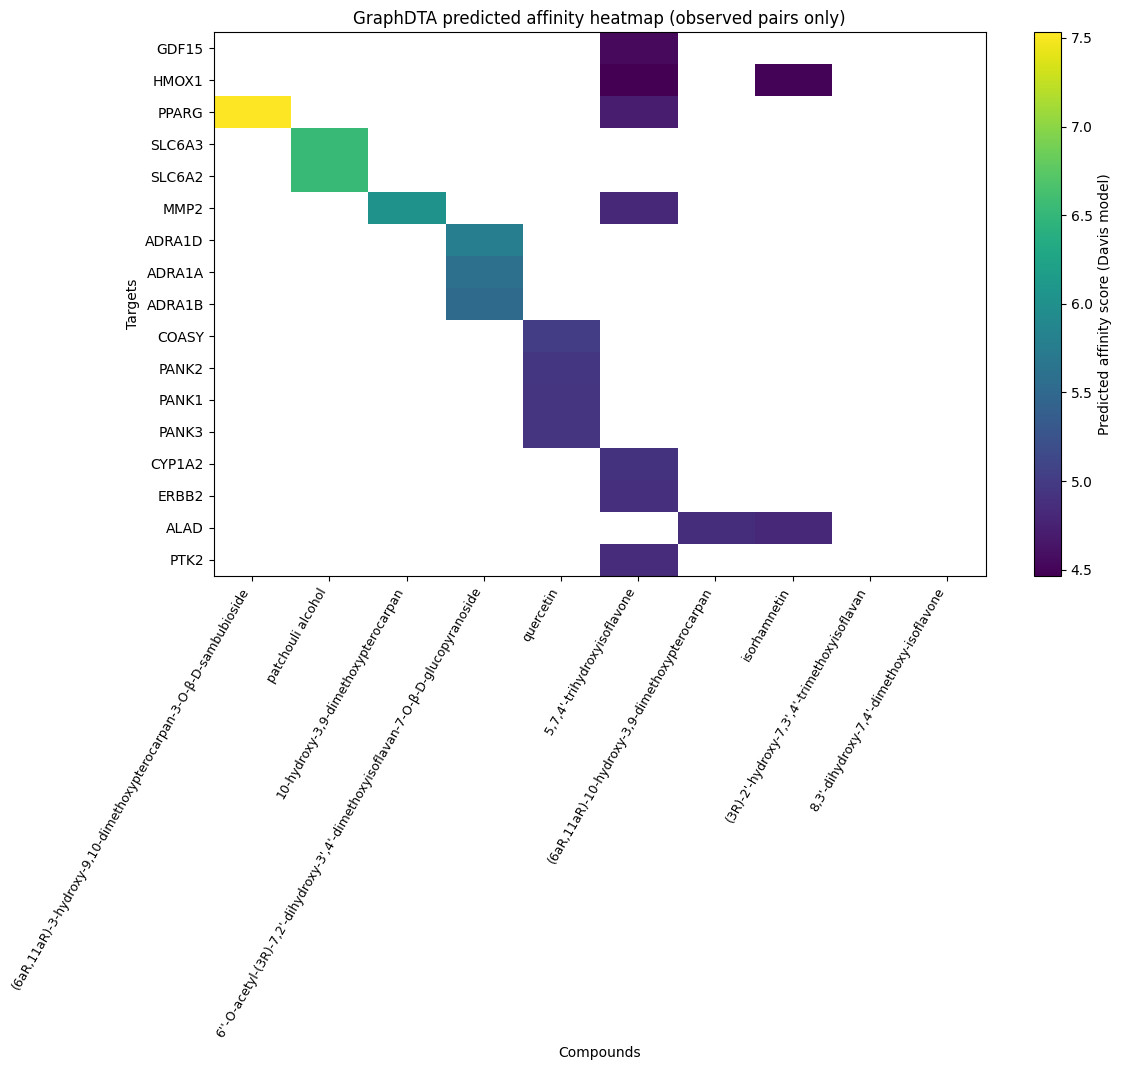

[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\figures\Fig2_heatmap_masked_val.png


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pred_file = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\graphdta_predictions_davis_val.csv"
df = pd.read_csv(pred_file)

# pivot (존재하는 pair만 값이 있음)
pivot = df.pivot_table(index="gene_symbol", columns="label", values="pred_davis", aggfunc="max")

# 보기 좋게: target/compound 정렬(선택)
# - target은 axis_tag 있는 것 먼저
axis_targets = sorted(df.loc[df["axis_tag"].notna() & (df["axis_tag"].astype(str) != ""), "gene_symbol"].unique())
# 상위 타겟 일부만
top_targets = (df.groupby("gene_symbol")["pred_davis"].max().sort_values(ascending=False).head(15).index.tolist())
selected_targets = list(dict.fromkeys(axis_targets + top_targets))
pivot = pivot.loc[[t for t in selected_targets if t in pivot.index]]

# compound도 상위 N개만
top_compounds = pivot.max(axis=0).sort_values(ascending=False).head(10).index
pivot = pivot[top_compounds]

data = pivot.values
masked = np.ma.masked_invalid(data)  # NaN을 마스크

plt.figure(figsize=(max(10, 0.6*len(pivot.columns)+6), max(6, 0.4*len(pivot.index)+4)))

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="white")  # NaN은 흰색

im = plt.imshow(masked, aspect="auto", cmap=cmap)
plt.colorbar(im, label="Predicted affinity score (Davis model)")

plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=60, ha="right", fontsize=9)

plt.title("GraphDTA predicted affinity heatmap (observed pairs only)")
plt.xlabel("Compounds")
plt.ylabel("Targets")

plt.tight_layout()
out = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\figures\Fig2_heatmap_masked_val.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print("[DONE] Saved:", out)

In [19]:
import pandas as pd
import os

BASE = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2"
pred_file = os.path.join(BASE, "graphdta_predictions_davis_val.csv")

df = pd.read_csv(pred_file)
df["axis_tag"] = df["axis_tag"].fillna("UNLABELED")

# ---- Figure 1용 edge 선택 ----
# 1) axis edge는 모두 포함
axis_df = df[df["axis_tag"] != "UNLABELED"].copy()

# 2) 각 target별 top 2 ligand 추가
top2 = (df.sort_values(["gene_symbol", "pred_davis"], ascending=[True, False])
          .groupby("gene_symbol", as_index=False)
          .head(2)
          .copy())

fig_edges = pd.concat([axis_df, top2], axis=0).drop_duplicates(
    subset=["label", "gene_symbol", "protein_id"]
).copy()

print("[INFO] figure edges:", len(fig_edges))
print("[INFO] compounds:", fig_edges["label"].nunique())
print("[INFO] targets:", fig_edges["gene_symbol"].nunique())

# Cytoscape edge table
edge_table = fig_edges[[
    "label", "gene_symbol", "protein_id", "combined_score", "pred_davis", "axis_tag", "PubChem_CID"
]].copy()
edge_table = edge_table.rename(columns={
    "label": "source",
    "gene_symbol": "target"
})

edge_out = os.path.join(BASE, "cytoscape_edges_graphdta_figure1_val.tsv")
edge_table.to_csv(edge_out, sep="\t", index=False)

# Cytoscape node table
compound_nodes = pd.DataFrame({
    "id": sorted(fig_edges["label"].unique()),
    "node_type": "compound",
    "axis_tag": "",
    "display_name": sorted(fig_edges["label"].unique())
})

target_axis = (fig_edges[["gene_symbol", "axis_tag"]]
               .drop_duplicates()
               .rename(columns={"gene_symbol": "id"}))
target_axis["node_type"] = "target"
target_axis["display_name"] = target_axis["id"]

node_table = pd.concat([
    compound_nodes[["id", "display_name", "node_type", "axis_tag"]],
    target_axis[["id", "display_name", "node_type", "axis_tag"]]
], axis=0).drop_duplicates()

node_out = os.path.join(BASE, "cytoscape_nodes_graphdta_figure1_val.tsv")
node_table.to_csv(node_out, sep="\t", index=False)

print("[DONE] Saved:", edge_out)
print("[DONE] Saved:", node_out)

[INFO] figure edges: 36
[INFO] compounds: 11
[INFO] targets: 32
[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\cytoscape_edges_graphdta_figure1_val.tsv
[DONE] Saved: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\cytoscape_nodes_graphdta_figure1_val.tsv


C:\Users\GM\AppData\Local\Temp\ipykernel_27544\3426093464.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis").copy()


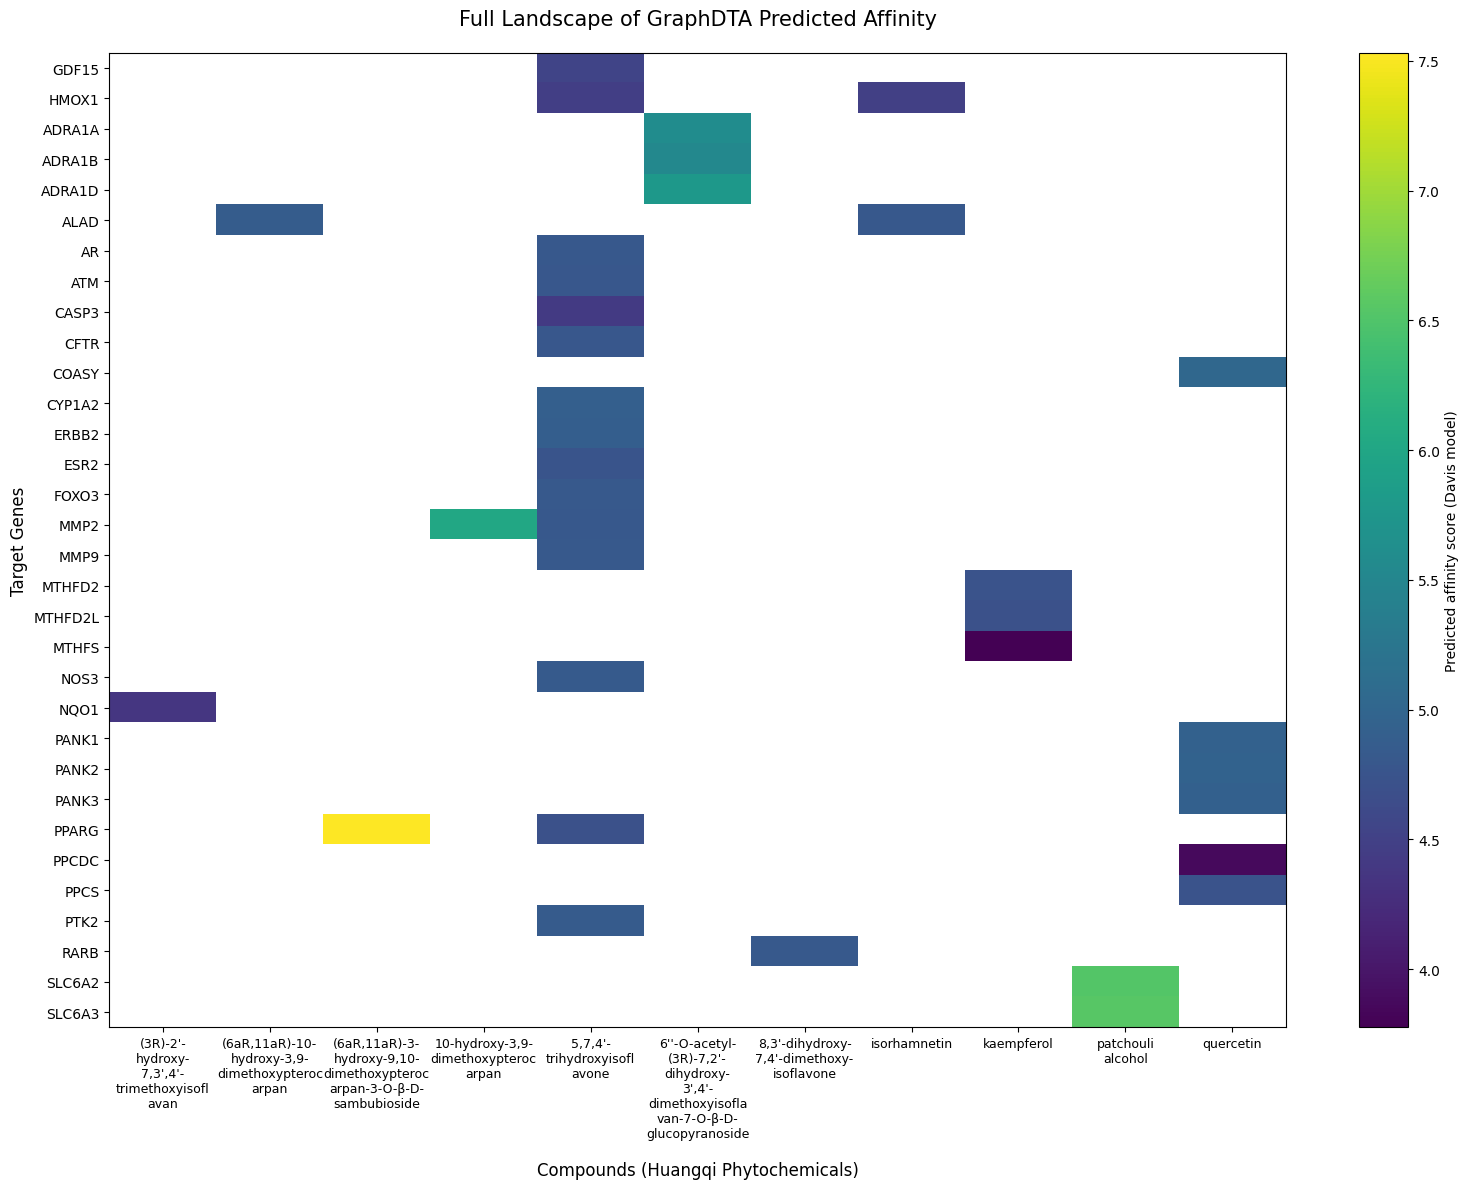

[DONE] 전체 32개 타겟과 11개 화합물에 대한 히트맵이 저장되었습니다.
경로: G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\figures\Fig2_heatmap_full_landscape_val.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import os

# 1. 데이터 로드
pred_file = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\graphdta_predictions_davis_val.csv"
df = pd.read_csv(pred_file)

# 2. Pivot Table 생성 (32개 타겟 x 11개 화합물 전체)
# 데이터프레임에 존재하는 모든 unique한 gene과 label이 자동으로 포함됩니다.
pivot = df.pivot_table(index="gene_symbol", columns="label", values="pred_davis", aggfunc="max")

# 3. 정렬 (선택 사항: 보기 좋게 하기 위해 축 타겟을 위로 올림)
axis_targets = sorted(df.loc[df["axis_tag"].notna() & (df["axis_tag"].astype(str) != ""), "gene_symbol"].unique())
other_targets = sorted([g for g in pivot.index if g not in axis_targets])
pivot = pivot.reindex(axis_targets + other_targets)

# 4. 시각화 설정
# 데이터가 많아졌으므로 피규어 사이즈를 충분히 키웁니다.
plt.figure(figsize=(16, 12)) 

# X축 라벨(화합물 이름) 줄바꿈 처리 (15자 기준)
wrapped_labels = [textwrap.fill(label, width=15) for label in pivot.columns]

data = pivot.values
masked = np.ma.masked_invalid(data) # 데이터가 없는 쌍은 흰색 처리

cmap = plt.cm.get_cmap("viridis").copy()
cmap.set_bad(color="white")

# 히트맵 그리기
im = plt.imshow(masked, aspect="auto", cmap=cmap)
plt.colorbar(im, label="Predicted affinity score (Davis model)")

# 축 라벨 설정
plt.yticks(range(len(pivot.index)), pivot.index, fontsize=10)
plt.xticks(range(len(pivot.columns)), wrapped_labels, rotation=0, fontsize=9) # 개행이 들어가므로 0도 혹은 살짝만 회전

plt.title("Full Landscape of GraphDTA Predicted Affinity", fontsize=15, pad=20)
plt.xlabel("Compounds (Huangqi Phytochemicals)", fontsize=12, labelpad=15)
plt.ylabel("Target Genes", fontsize=12)

plt.tight_layout()

# 5. 저장 및 출력
out_dir = r"G:\내 드라이브\★Works\NP and ML\Huangqi\out_stage2_v2\figures"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "Fig2_heatmap_full_landscape_val.png")

plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[DONE] 전체 {pivot.shape[0]}개 타겟과 {pivot.shape[1]}개 화합물에 대한 히트맵이 저장되었습니다.")
print(f"경로: {out_path}")